# Official HEC-HMS Guide Mirror: Calibration and Validation

Official guide: https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/model-calibration-and-validation

This notebook maps the official calibration and validation workflow to hms-commander primitives: compute a baseline run, overlay observed and modeled hydrographs, inspect residuals, generate a calibration script scaffold, and demonstrate a real before/after routing-roughness run using the River Bend sample.

## HEC-HMS Documentation Alignment

| Notebook checkpoint | HEC-HMS reference |
|---|---|
| Calibration concepts and fit statistics | [Technical Reference: Calibration](https://www.hec.usace.army.mil/confluence/hmsdocs/hmstrm/calibration) |
| GUI calibration and validation workflow | [Guide: Model Calibration and Validation](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsguides/model-calibration-and-validation) |
| Optimization-trial workflow for automated calibration | [User's Manual: Optimization Trials](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsum/latest/model-optimization/optimization-trials) |
| Optimization result review | [User's Manual: Computing Results for a Trial](https://www.hec.usace.army.mil/confluence/hmsdocs/hmsum/4.12/model-optimization/computing-results-for-a-trial) |


In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

logging.disable(logging.CRITICAL)


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "hms_commander").is_dir() and (candidate / "examples").is_dir():
            return candidate
    return start


REPO_ROOT = find_repo_root()
WORK_ROOT = REPO_ROOT / "examples" / "working" / "clb238_guides"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
HMS_VERSION = "4.13"

from hms_commander import HmsExamples, HmsPrj

available_versions = HmsExamples.list_versions()
if HMS_VERSION not in available_versions:
    HMS_VERSION = available_versions[0]
HMS_EXE = HmsExamples.get_hms_exe(HMS_VERSION)


def init_sample_project(project_name, notebook_key, overwrite=True):
    project_path = HmsExamples.extract_project(
        project_name,
        version=HMS_VERSION,
        output_path=WORK_ROOT / notebook_key,
        overwrite=overwrite,
    )
    project = HmsPrj()
    project.initialize(project_path, hms_exe_path=HMS_EXE)
    return project, project_path

In [2]:
from hms_commander import HmsBasin, HmsCmdr, HmsDss, HmsJython
from hms_commander._parsing import HmsFileParser

project, project_path = init_sample_project("castro", "105_calibration_validation/castro")
run_name = "Current"
config = project.get_run_configuration(run_name)

success = HmsCmdr.compute_run(
    run_name,
    hms_object=project,
    timeout=120,
    save_project=False,
    max_memory="2G",
)
assert success

dss_file = project_path / config["dss_file"]
catalog = HmsDss.get_catalog(dss_file)
modeled_path = next(path for path in catalog if "//OUTLET/FLOW/" in path.upper())
observed_path = next(path for path in catalog if "//OUTLET/FLOW-OBSERVED/" in path.upper())
modeled = HmsDss.read_timeseries(dss_file, modeled_path)[["value"]].rename(columns={"value": "modeled_cfs"})
observed = HmsDss.read_timeseries(dss_file, observed_path)[["value"]].rename(columns={"value": "observed_cfs"})
comparison = observed.join(modeled, how="inner")
comparison["residual_cfs"] = comparison["modeled_cfs"] - comparison["observed_cfs"]

rmse = float(np.sqrt(np.mean(comparison["residual_cfs"] ** 2)))
nse = 1.0 - float(((comparison["observed_cfs"] - comparison["modeled_cfs"]) ** 2).sum()) / float(((comparison["observed_cfs"] - comparison["observed_cfs"].mean()) ** 2).sum())
observed_peak_time = comparison["observed_cfs"].idxmax()
modeled_peak_time = comparison["modeled_cfs"].idxmax()
interval_hours = float(comparison.index.to_series().diff().dropna().median() / pd.Timedelta(hours=1))
observed_volume = float(comparison["observed_cfs"].sum() * interval_hours)
modeled_volume = float(comparison["modeled_cfs"].sum() * interval_hours)

calibration_stats = pd.DataFrame([{
    "run_name": run_name,
    "time_steps": len(comparison),
    "observed_peak_cfs": round(float(comparison["observed_cfs"].max()), 1),
    "modeled_peak_cfs": round(float(comparison["modeled_cfs"].max()), 1),
    "rmse_cfs": round(rmse, 2),
    "nash_sutcliffe_efficiency": round(nse, 3),
}])
calibration_event_summary = pd.DataFrame([{
    "observed_peak_time": observed_peak_time,
    "modeled_peak_time": modeled_peak_time,
    "peak_time_error_hours": round(float((modeled_peak_time - observed_peak_time) / pd.Timedelta(hours=1)), 2),
    "observed_volume_proxy_cfs_hr": round(observed_volume, 1),
    "modeled_volume_proxy_cfs_hr": round(modeled_volume, 1),
    "volume_bias_pct": round((modeled_volume / observed_volume - 1.0) * 100.0, 2),
}])

display(calibration_stats)
display(calibration_event_summary)


Configuring Java VM for DSS operations...
  Found Java: C:\Program Files\HEC\HEC-HMS\4.9\jre
[OK] Java VM configured


,run_name,time_steps,observed_peak_cfs,modeled_peak_cfs,rmse_cfs,nash_sutcliffe_efficiency
0,Current,120,537.0,540.3,63.94,0.863


,observed_peak_time,modeled_peak_time,peak_time_error_hours,observed_volume_proxy_cfs_hr,modeled_volume_proxy_cfs_hr,volume_bias_pct
0,1973-01-16 07:40:00,1973-01-16 06:55:00,-0.75,2910.5,2940.4,1.03


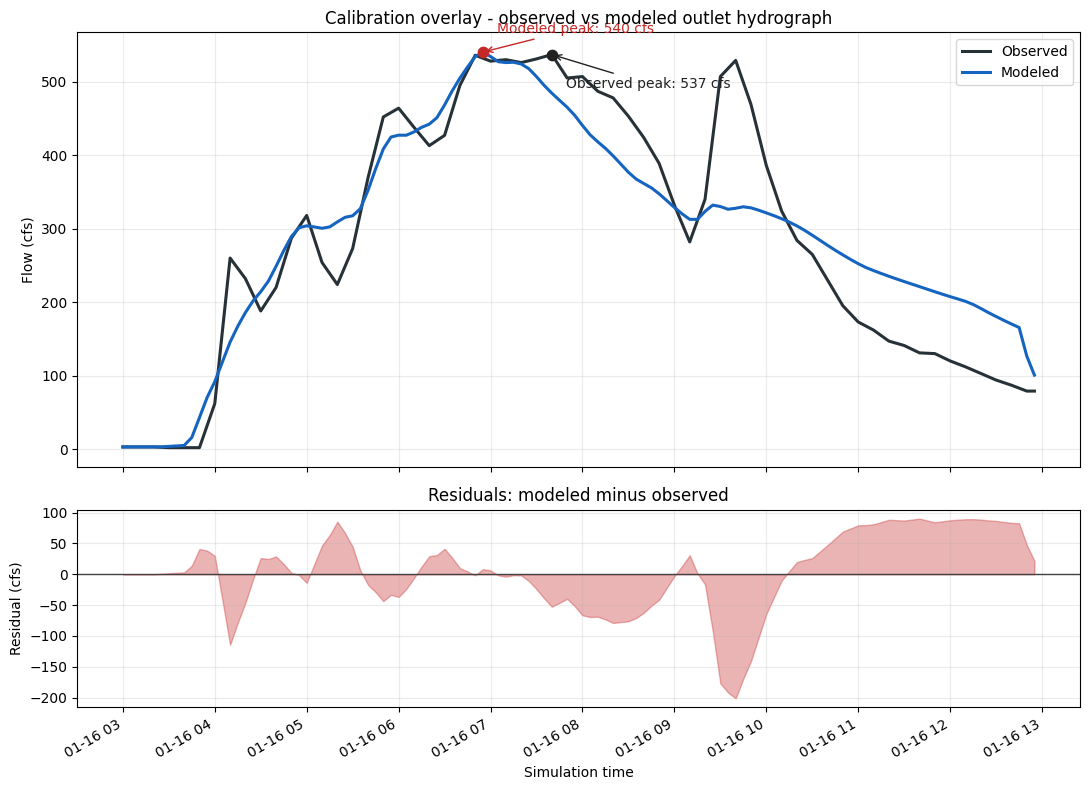

In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, height_ratios=[2.2, 1])
ax1.plot(comparison.index, comparison["observed_cfs"], color="#263238", linewidth=2.2, label="Observed")
ax1.plot(comparison.index, comparison["modeled_cfs"], color="#1565c0", linewidth=2.2, label="Modeled")
for label, column, color in [
    ("Observed peak", "observed_cfs", "#212121"),
    ("Modeled peak", "modeled_cfs", "#c62828"),
]:
    peak_time = comparison[column].idxmax()
    peak_value = comparison.loc[peak_time, column]
    ax1.scatter([peak_time], [peak_value], color=color, s=55, zorder=3)
    ax1.annotate(
        f"{label}: {peak_value:.0f} cfs",
        xy=(peak_time, peak_value),
        xytext=(10, 14 if column == "modeled_cfs" else -24),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->", "color": color},
        color=color,
    )
ax1.set_title("Calibration overlay - observed vs modeled outlet hydrograph")
ax1.set_ylabel("Flow (cfs)")
ax1.grid(True, alpha=0.25)
ax1.legend()

ax2.axhline(0, color="#424242", linewidth=1)
ax2.fill_between(comparison.index, comparison["residual_cfs"], 0, color="#c62828", alpha=0.35)
ax2.set_title("Residuals: modeled minus observed")
ax2.set_ylabel("Residual (cfs)")
ax2.set_xlabel("Simulation time")
ax2.grid(True, alpha=0.25)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


In [4]:
basin_path = Path(config["basin_file"])
subbasins = HmsBasin.get_subbasins(basin_path)
first_subbasin = subbasins.iloc[0]["name"]
calibration_parameters = {first_subbasin: {"InitialLoss": 0.03, "SnyderTp": 0.25}}
calibration_script = HmsJython.generate_calibration_script(
    project_path,
    run_name,
    calibration_parameters,
    basin_name=config["basin_name"],
    hms_object=project,
)
candidate_grid = pd.DataFrame([
    {"element": first_subbasin, "parameter": "InitialLoss", "candidate_value": value}
    for value in [0.01, 0.02, 0.03, 0.04]
] + [
    {"element": first_subbasin, "parameter": "SnyderTp", "candidate_value": value}
    for value in [0.16, 0.20, 0.24, 0.28]
])
script_check = pd.DataFrame([
    {"check": "contains CALIBRATION_PARAMS marker", "passed": "CALIBRATION_PARAMS" in calibration_script},
    {"check": "contains selected subbasin", "passed": first_subbasin in calibration_script},
    {"check": "contains run name", "passed": run_name in calibration_script},
])
assert script_check["passed"].all()
display(script_check)
display(candidate_grid)

,check,passed
0,contains CALIBRATION_PARAMS marker,True
1,contains selected subbasin,True
2,contains run name,True


,element,parameter,candidate_value
0,Subbasin-3,InitialLoss,0.01
1,Subbasin-3,InitialLoss,0.02
2,Subbasin-3,InitialLoss,0.03
3,Subbasin-3,InitialLoss,0.04
4,Subbasin-3,SnyderTp,0.16
5,Subbasin-3,SnyderTp,0.20
6,Subbasin-3,SnyderTp,0.24
7,Subbasin-3,SnyderTp,0.28


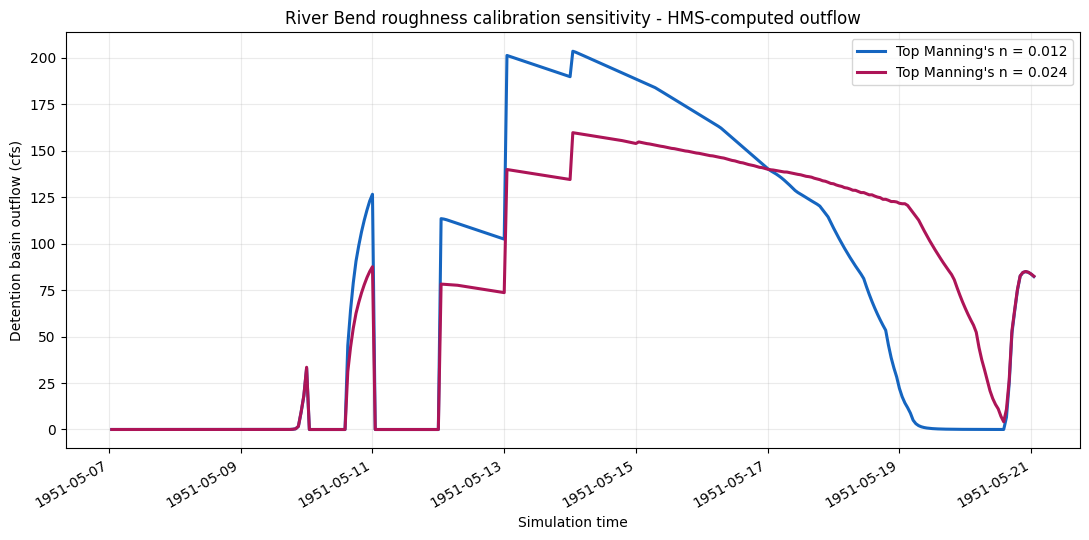

,case,top_mannings_n,peak_cfs,peak_time,annual_volume_proxy_cfs_hr
0,n_0_012,0.012,203.5,1951-05-14 01:00:00,273194.3
1,n_0_024,0.024,159.7,1951-05-14 01:00:00,273188.2


In [5]:
def compute_river_bend_manning_case(case_key, top_mannings_n):
    case_project, case_path = init_sample_project(
        "river_bend",
        f"105_calibration_validation/river_bend_{case_key}",
        overwrite=True,
    )
    basin_file = case_path / "Minimum_Facility.basin"
    content = HmsFileParser.read_file(basin_file)
    updated, changed = HmsFileParser.update_parameter(content, "Top Manning's n", top_mannings_n)
    assert changed, "Expected River Bend sample to contain Top Manning's n"
    HmsFileParser.write_file(basin_file, updated)

    case_project.initialize(case_path, hms_exe_path=HMS_EXE)
    run = "Minimum Facility"
    ok = HmsCmdr.compute_run(run, hms_object=case_project, timeout=180, save_project=False, max_memory="2G")
    assert ok
    dss = case_path / case_project.get_run_configuration(run)["dss_file"]
    flow_path = next(
        path for path in HmsDss.get_catalog(dss)
        if "//DETENTION BASIN/FLOW/" in path.upper() and "01JAN1951" in path.upper()
    )
    flow = HmsDss.read_timeseries(dss, flow_path)[["value"]].rename(columns={"value": case_key})
    return flow, flow_path

manning_cases = {"n_0_012": 0.012, "n_0_024": 0.024}
manning_results = {}
manning_paths = {}
for case_key, top_n in manning_cases.items():
    manning_results[case_key], manning_paths[case_key] = compute_river_bend_manning_case(case_key, top_n)

manning_compare = pd.concat(manning_results.values(), axis=1).dropna()
peak_time = manning_compare["n_0_012"].idxmax()
window = manning_compare.loc[peak_time - pd.Timedelta(days=7): peak_time + pd.Timedelta(days=7)]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(window.index, window["n_0_012"], color="#1565c0", linewidth=2.2, label="Top Manning's n = 0.012")
ax.plot(window.index, window["n_0_024"], color="#ad1457", linewidth=2.2, label="Top Manning's n = 0.024")
ax.set_title("River Bend roughness calibration sensitivity - HMS-computed outflow")
ax.set_xlabel("Simulation time")
ax.set_ylabel("Detention basin outflow (cfs)")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

manning_summary = pd.DataFrame([
    {
        "case": case_key,
        "top_mannings_n": top_n,
        "peak_cfs": round(float(manning_compare[case_key].max()), 1),
        "peak_time": manning_compare[case_key].idxmax(),
        "annual_volume_proxy_cfs_hr": round(float(manning_compare[case_key].sum()), 1),
    }
    for case_key, top_n in manning_cases.items()
])
manning_summary

## Coverage Notes

The observed-vs-modeled and residual plots use Castro DSS outputs. The roughness plot uses a River Bend clone because that HMS sample contains a conduit `Top Manning's n` parameter; hms-commander does not yet expose a public reservoir-conduit Manning setter, so this notebook uses the shared HMS file parser as an explicit API-gap workaround.

## What You Should See in the HMS GUI

For the Castro project, the Results tab should show observed and computed outlet flow time series comparable to the overlay and residual plots. For the River Bend roughness clones, the Detention Basin flow result should change between the two Manning's n cases, and the peak/volume table should identify the direction of sensitivity.
